In [15]:
import csv
import numpy as np
from numpy import mean
from numpy import std
from numpy import dstack
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical
import keras
import tensorflow as tf
from keras.models import Sequential
from keras import layers
from keras.utils import plot_model
from keras.optimizers import Adam
from keras.models import Model
from keras.layers import Conv1D, Dense, MaxPooling1D, Flatten, Input, Dropout, concatenate

In [20]:
cd G:/PRPD

G:\PRPD


In [22]:
X = np.load("X_transformer_preprocess.npy")
y = np.loadtxt("y_labels_preprocess.txt", dtype=int)
print(X.shape, y.shape)

(567, 50, 1200) (567,)


In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(453, 50, 1200) (453, 4) (114, 50, 1200) (114, 4)


In [24]:
n_outputs = y_train.shape[1]
MAX_SEQ_LENGTH = X_train.shape[1]
NUM_FEATURES = X_train.shape[2]
EPOCHS = 30

class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, output_dim, **kwargs):
        super().__init__(**kwargs)
        self.position_embeddings = layers.Embedding(
            input_dim=sequence_length, output_dim=output_dim
        )
        self.sequence_length = sequence_length
        self.output_dim = output_dim

    def call(self, inputs):
        # The inputs are of shape: `(batch_size, frames, num_features)`
        length = tf.shape(inputs)[1]
        positions = tf.range(start=0, limit=length, delta=1)
        embedded_positions = self.position_embeddings(positions)
        return inputs + embedded_positions

    # def compute_mask(self, inputs, mask=None):
    #     mask = tf.reduce_any(tf.cast(inputs, "bool"), axis=-1)
    #     return mask


class TransformerEncoder(layers.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.dense_dim = dense_dim
        self.num_heads = num_heads
        self.attention = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim, dropout=0.3
        )
        self.dense_proj = keras.Sequential(
            [layers.Dense(dense_dim, activation=tf.nn.gelu), layers.Dense(embed_dim), ]
        )
        self.layernorm_1 = layers.LayerNormalization()
        self.layernorm_2 = layers.LayerNormalization()

    def call(self, inputs, mask=None):
        if mask is not None:
            mask = mask[:, tf.newaxis, :]

        attention_output = self.attention(inputs, inputs, attention_mask=mask)
        proj_input = self.layernorm_1(inputs + attention_output)
        proj_output = self.dense_proj(proj_input)
        return self.layernorm_2(proj_input + proj_output)

In [28]:
def get_compiled_model():
    sequence_length = MAX_SEQ_LENGTH
    embed_dim = NUM_FEATURES
    dense_dim = 4
    num_heads = 1

    inputs = keras.Input(shape=(MAX_SEQ_LENGTH, NUM_FEATURES))
    x = PositionalEmbedding(
        sequence_length, embed_dim, name="frame_position_embedding"
    )(inputs)
    x = TransformerEncoder(embed_dim, dense_dim, num_heads, name="transformer_layer")(inputs)
    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(n_outputs, activation="softmax")(x)
    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"]
    )
    return model

def run_experiment():
    filepath = "./PRPD_classifier_model/transformer_1200.ckpt"
    checkpoint = tf.keras.callbacks.ModelCheckpoint(filepath=filepath, verbose=1, save_weights_only=True, save_freq="epoch")

    model = get_compiled_model()
    history = model.fit(
        X_train,
        y_train,
        validation_split=0.15,
        epochs=EPOCHS,
        callbacks=[checkpoint],
    )

    model.load_weights(filepath)
    _, accuracy = model.evaluate(X_test, y_test)
    print(f"Test accuracy: {round(accuracy * 100, 2)}%")
    return model, history

In [29]:
model = get_compiled_model()
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 50, 1200)]        0         
                                                                 
 transformer_layer (Transfo  (None, 50, 1200)          5780404   
 rmerEncoder)                                                    
                                                                 
 global_max_pooling1d (Glob  (None, 1200)              0         
 alMaxPooling1D)                                                 
                                                                 
 dropout (Dropout)           (None, 1200)              0         
                                                                 
 dense_4 (Dense)             (None, 4)                 4804      
                                                                 
Total params: 5785208 (22.07 MB)
Trainable params: 5785208 (2

In [30]:
trained_model, history = run_experiment()

Epoch 1/30
13/13 [==============================] - ETA: 0s - loss: 0.3352 - accuracy: 0.9221
Epoch 1: saving model to ./PRPD_classifier_model\transformer_1200.ckpt
13/13 [==============================] - 12s 647ms/step - loss: 0.3352 - accuracy: 0.9221 - val_loss: 9.7778e-05 - val_accuracy: 1.0000
Epoch 2/30
13/13 [==============================] - ETA: 0s - loss: 0.0056 - accuracy: 0.9974
Epoch 2: saving model to ./PRPD_classifier_model\transformer_1200.ckpt
13/13 [==============================] - 9s 679ms/step - loss: 0.0056 - accuracy: 0.9974 - val_loss: 5.4953e-04 - val_accuracy: 1.0000
Epoch 3/30
13/13 [==============================] - ETA: 0s - loss: 0.0133 - accuracy: 0.9922
Epoch 3: saving model to ./PRPD_classifier_model\transformer_1200.ckpt
13/13 [==============================] - 8s 620ms/step - loss: 0.0133 - accuracy: 0.9922 - val_loss: 0.1079 - val_accuracy: 0.9559
Epoch 4/30
13/13 [==============================] - ETA: 0s - loss: 0.0045 - accuracy: 1.0000
Epoch 4: 

In [ ]:
trained_model.save("./PRPD_classifier_model/transformer1200.h5")

In [ ]:
ans = history.history['accuracy']
len(ans)

30

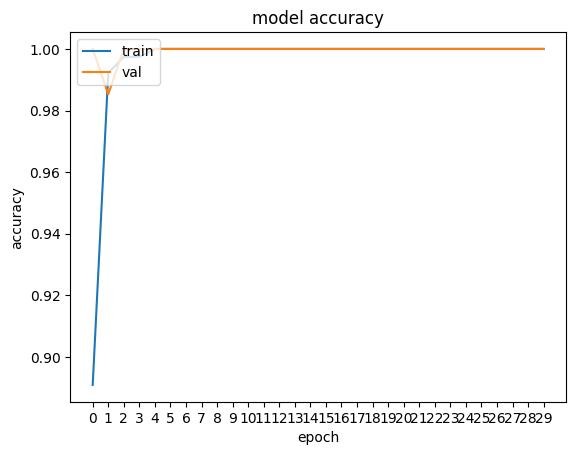

In [ ]:
plt.plot(history.history['accuracy'])
plt.xticks(range(0,30))
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

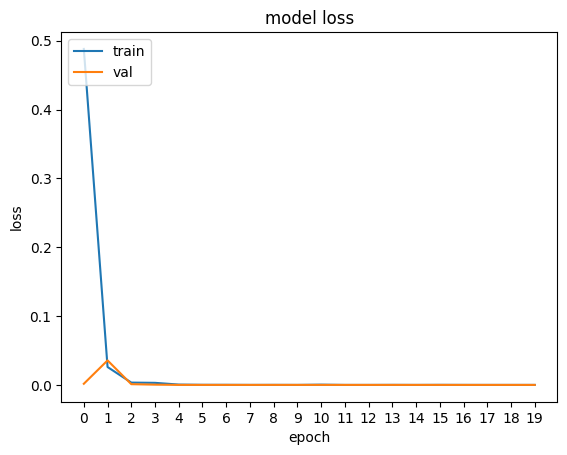

In [ ]:
plt.plot(history.history['loss'][:20])
plt.xticks(range(0,20))
plt.plot(history.history['val_loss'][:20])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()